<a href="https://colab.research.google.com/github/DACSS690C26/Homework_1/blob/main/hm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 1 DACSS690C
Spatial Autocorrelation
Patrick McGrath
Summer 2026

In [136]:
#Install needed Libraries
#!pip show pysal pandas geopandas libpysal esda
import geopandas as gpd
import pandas as pd
## Set random seed for reproducibility:
from numpy.random import seed
seed(42)

In [137]:
#Pull needed data from GITHUB Repo
peru_link = "https://github.com/DACSS690C26/Homework_1/raw/main/PeruMaps.gpkg"


peru_df = gpd.read_file(peru_link,layer='good_geom')
#peru_df

peru_df=peru_df.to_crs(5387)
#peru_df.plot()

#Keep the DEPARTAMENTO of 'LIMA'
lima_data=peru_df[peru_df['DEPARTAMENTO']=='Lima']

#lima_data[lima_data['DISTRITO'].duplicated()]
lima_data.set_index('DISTRITO', inplace=True)


In [138]:
lima_data.Educ_sec_comp2019_pct.describe()

,Educ_sec_comp2019_pct
count,171.000000
mean,64.528993
std,14.867417
min,12.358409
25%,56.828850
50%,67.618560
75%,76.540106
max,89.215043


Try using his data first and then go from there

Try with US data first and work back from there

In [139]:
LinkPeru="https://github.com/DACSS-CSSmeths-summer/datafiles/raw/main/PeruMaps.gpkg"
peru=gpd.read_file(LinkPeru,layer='good_geom')
# basic description
#peru.info()

peru.crs.to_epsg(),\
peru.crs.is_projected, \
set(peru.geom_type)

peru=peru.to_crs(5387)
#peru.plot()

lima=peru[peru['DEPARTAMENTO']=='Lima']
lima

#lima.set_index('DISTRITO', inplace=True)

lima.Educ_sec_comp2019_pct.describe()

lima_queen=Graph.build_contiguity(lima,rook=False)

toWideMatrix=lambda g:pd.DataFrame(g.adjacency).unstack().fillna(0)

queen_lima_Matrix=toWideMatrix(lima_queen)
queen_lima_Matrix

weight                                               ...            \
neighbor   39   40   54   65   71   86   93   102  109  110   ... 1726 1751   
focal                                                         ...             
39          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  0.0   
40          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
54          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
65          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
71          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
1799        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1804        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1813        1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  0.0   
1850        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1871        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

                                                  
neighbor 1781 1783 1797 1799 1804 1813 1850 1871  
focal                                             
39        0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  
40        0.0  0.0  0.0  0.0  1.0  0.0  1.0  1.0  
54        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
65        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
71        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
...       ...  ...  ...  ...  ...  ...  ...  ...  
1799      0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  
1804      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1813      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1850      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1871      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[171 rows x 171 columns]

In [140]:



#  "islands" may create trouble.
# Should you keep using a _contiguity_ approach, you may consider filtering those out
lima_queen.isolates

lima_queen=lima_queen.transform("r")

ylag = lima_queen.lag(lima["Educ_sec_comp2019_pct"])

lima=lima.assign(Educ_sec_comp2019_pct_lagged=ylag)
lima.head()

,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry,Educ_sec_comp2019_pct_lagged
39,Lima,YAUYOS,ALIS,PE151002,1233,0.646897,69.474298,30.3,6.6,"MULTIPOLYGON (((415396.076 8647591.116, 415450...",46.580156
40,Lima,YAUYOS,AYAUCA,PE151003,2293,0.544152,43.167400,61.9,57.2,"MULTIPOLYGON (((389530.693 8626520.884, 389743...",60.012500
54,Lima,HUAURA,AMBAR,PE150802,2761,0.316448,42.060097,73.3,60.2,"MULTIPOLYGON (((243293.978 8826436.11, 243328....",54.147482
65,Lima,LIMA,ANCON,PE150102,42124,0.668889,72.117976,21.7,1.1,"MULTIPOLYGON (((281417 8715329, 281397.439 871...",67.086008
71,Lima,OYON,ANDAJES,PE150902,1058,0.488913,71.684369,36.4,28.5,"MULTIPOLYGON (((291522.945 8820149.937, 291499...",52.353706


<Axes: xlabel='Educ_sec_comp2019_pct', ylabel='Educ_sec_comp2019_pct_lagged'>

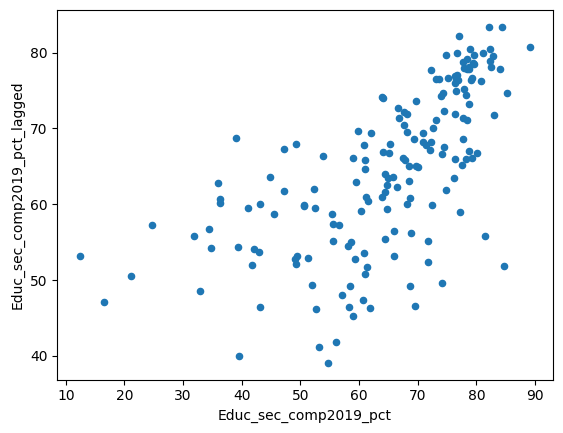

In [141]:
lima.plot.scatter("Educ_sec_comp2019_pct","Educ_sec_comp2019_pct_lagged")

In [142]:
import esda # from pysal

MoranGlobal_HS = esda.Moran(lima['Educ_sec_comp2019_pct'], lima_queen)
MoranGlobal_HS.I,MoranGlobal_HS.p_sim

(np.float64(0.4569992839296947), np.float64(0.001))

In [143]:
lisa = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], lima_queen)

<Axes: >

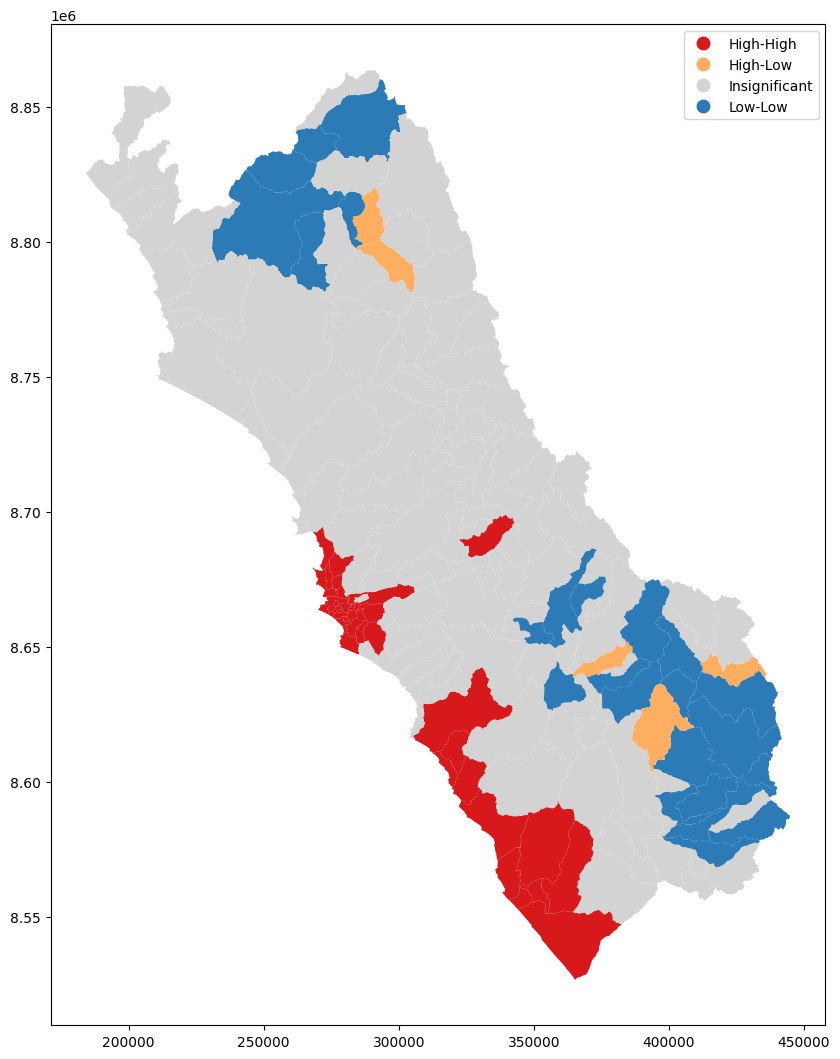

In [144]:
lisa.plot(lima,crit_value=0.05,figsize=(10,13),legend=True)

In [145]:
# get the quadrants
lima['HS_lisa'] = lisa.get_cluster_labels(crit_value=0.05)
# see the count
lima['HS_lisa'].value_counts()

,count
HS_lisa,
Insignificant,103
High-High,39
Low-Low,23
High-Low,6


In [146]:
TheStats=["mean", "min", "max","var"]


# stats by the lisa cluster
grouped_stats = lima.groupby('HS_lisa')['Educ_sec_comp2019_pct'].agg(TheStats)

# stats for the entire, ungrouped column
global_stats = lima['Educ_sec_comp2019_pct'].agg(TheStats)

# Convert 'global_stats' (Series) to a DataFrame with an appropriate index name
global_stats_df = pd.DataFrame(global_stats).T
global_stats_df.index = ['Global/Total'] # simple but key

# Combine both
pd.concat([grouped_stats, global_stats_df])

,mean,min,max,var
High-High,78.426636,66.653554,89.215043,15.179261
High-Low,73.386075,68.601779,84.743374,34.726328
Insignificant,62.286290,16.477878,85.209470,184.903524
Low-Low,48.696294,12.358409,61.943082,167.241844
Global/Total,64.528993,12.358409,89.215043,221.040099


In [147]:
##knowing
lima['HS_lisa'].unique()

oldLabels=['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High']
#oldLabels = ['Low-Low', 'Insignificant', 'High-Low', 'High-High']
# 3 will be at the middle
newLabels = ['3 no_pattern', '4 coldSpot','2 hotSpot','1 hotOutlier' , '5 coldOutlier']

labels = dict(zip(oldLabels, newLabels))

labels


{'Insignificant': '3 no_pattern',
 'Low-Low': '4 coldSpot',
 'High-High': '2 hotSpot',
 'High-Low': '1 hotOutlier',
 'Low-High': '5 coldOutlier'}

In [148]:


lima.replace({'HS_lisa':labels},inplace=True)

## see the count
lima['HS_lisa'].value_counts().sort_index()

,count
HS_lisa,
1 hotOutlier,6
2 hotSpot,39
3 no_pattern,103
4 coldSpot,23


<Axes: >

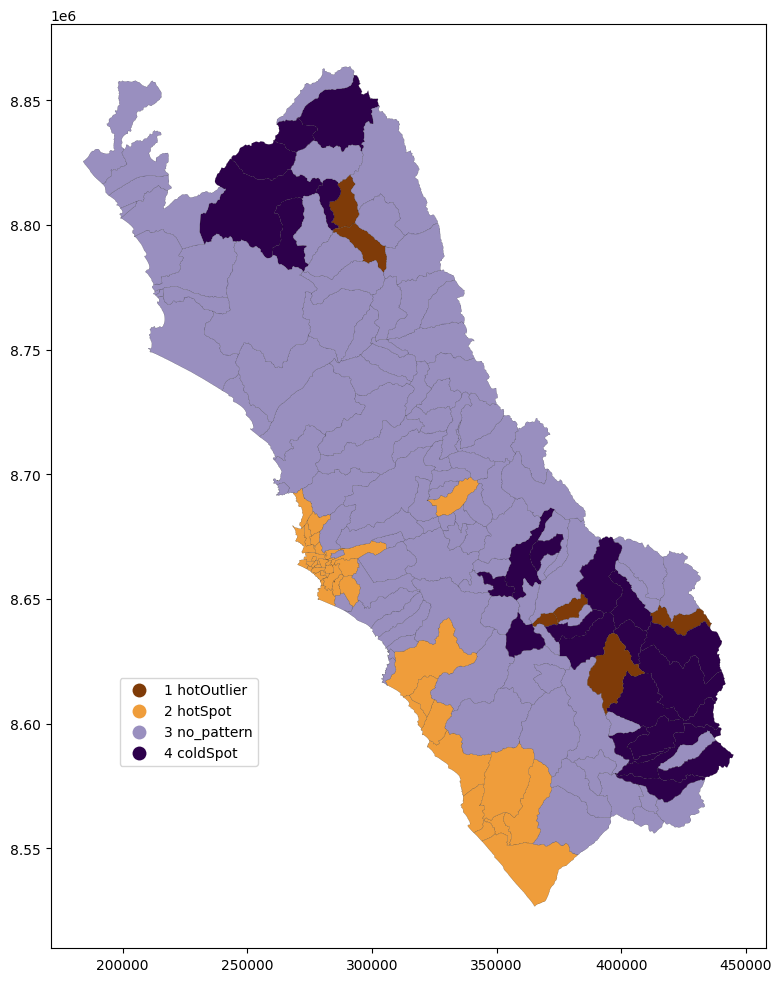

In [149]:
#custom colors- respect the previous order

import matplotlib.pyplot as plt
myColMap = plt.get_cmap('PuOr', 5)


##plot the map

lima.plot(column='HS_lisa',
                categorical=True,
                cmap=myColMap,
                linewidth=0.1,
                edgecolor='k',
                legend=True,
                legend_kwds={'bbox_to_anchor': (0.3, 0.3)},
                figsize=(12,12))